# Foundations of Physics-Informed Neural Networks (2019–2021)

**A reproducible review and computational study**

This notebook explains the first three years of the modern PINN literature through four connected ideas:

1. **Raissi–Perdikaris–Karniadakis (2019):** a neural representation trained by a composite loss containing data, initial/boundary conditions, and differential-equation residuals.
2. **Soft constraints and trainability:** the mathematical formulation is simple, but the optimization problem can be badly scaled.
3. **Stiff-PINN (Ji et al., 2021):** quasi-steady-state reduction can transform an untrainable stiff kinetic system into a mild system that a PINN can learn.
4. **NTK and gradient-pathology theory (2020–2021):** different loss blocks converge at different rates because their tangent kernels and gradients have very different spectra and magnitudes.

The notebook also includes a structured survey of major PINN papers published or released from **2019 through 2021 only**.

## TL;DR

A PINN is not “a neural network that knows physics.” It is a function approximator whose parameters are optimized so that several imperfect requirements are simultaneously small. The central object is therefore not only the PDE residual, but the **composite optimization problem**

$$
\mathcal L(\theta)=\lambda_f\mathcal L_f+\lambda_b\mathcal L_b+\lambda_d\mathcal L_d.
$$

The 2019 formulation made this construction general and practical. Work in 2020–2021 showed why it can fail: residual blocks may have incompatible scales, stiff systems contain unresolvable time scales, and the neural tangent kernel gives different convergence rates to different constraints. The practical response was a family of methods: adaptive weights, domain decomposition, variational losses, residual refinement, QSSA/model reduction, Bayesian formulations, and better architectures.

In [1]:
# Reproducible setup
import math, random, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 17
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ASSET_DIR = Path(__file__).parent / 'pinn_foundations_assets' if '__file__' in dir() else Path('pinn_foundations_assets')
ASSET_DIR.mkdir(exist_ok=True)
print('PyTorch:', torch.__version__, '| device:', device)

PyTorch: 2.13.0 | device: cpu


## 1. Survey method and boundaries

The literature table below is a **high-coverage, curated survey** of foundational and representative PINN work from 2019–2021. It includes peer-reviewed papers and influential preprints that materially changed formulation, optimization, theory, uncertainty quantification, decomposition, software, or applications.

It is not a claim that every domain-specific paper containing the phrase “physics-informed” is included. A truly exhaustive census requires subscription bibliographic indexes and a formal systematic-review protocol with duplicate removal and full-text screening. Here, the inclusion rule is narrower and more useful for learning: a work must contribute directly to the PINN method or demonstrate a technically important advance/application.

In [2]:
# Curated literature map. URLs point to DOI or arXiv records.
papers = [
(2019,'Raissi, Perdikaris & Karniadakis','Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear PDEs','Foundation','J. Computational Physics','10.1016/j.jcp.2018.10.045'),
(2019,'Pang, Lu & Karniadakis','fPINNs: Fractional physics-informed neural networks','Generalized equations','SIAM J. Scientific Computing','10.1137/18M1229845'),
(2019,'Zhu et al.','Physics-constrained deep learning for high-dimensional surrogate modeling and uncertainty quantification without labeled data','Surrogates/UQ','J. Computational Physics','10.1016/j.jcp.2019.02.035'),
(2019,'Yang & Perdikaris','Adversarial uncertainty quantification in physics-informed neural networks','Uncertainty','J. Computational Physics','10.1016/j.jcp.2019.05.027'),
(2019,'Zhang et al.','Quantifying total uncertainty in physics-informed neural networks for forward and inverse stochastic problems','Uncertainty','J. Computational Physics','10.1016/j.jcp.2019.07.048'),
(2019,'Lu et al.','DeepXDE: A deep learning library for solving differential equations (preprint)','Software/adaptivity','arXiv:1907.04502','arXiv:1907.04502'),
(2019,'Kharazmi, Zhang & Karniadakis','Variational physics-informed neural networks for solving partial differential equations','Variational PINNs','arXiv:1912.00873','arXiv:1912.00873'),
(2019,'Meng et al.','PPINN: Parareal physics-informed neural network for time-dependent PDEs (preprint)','Time decomposition','arXiv:1909.10145','arXiv:1909.10145'),
(2019,'Dwivedi, Parashar & Srinivasan','Distributed physics-informed neural network for data-efficient solution to PDEs','Domain decomposition','arXiv:1907.08967','arXiv:1907.08967'),
(2020,'Mao, Jagtap & Karniadakis','Physics-informed neural networks for high-speed flows','Fluid mechanics','CMAME','10.1016/j.cma.2019.112789'),
(2020,'Jagtap, Kharazmi & Karniadakis','Conservative physics-informed neural networks on discrete domains for conservation laws','Domain decomposition','CMAME','10.1016/j.cma.2020.113028'),
(2020,'Jagtap & Karniadakis','Extended physics-informed neural networks (XPINNs)','Domain decomposition','Commun. Computational Physics','10.4208/cicp.OA-2020-0164'),
(2020,'Meng et al.','PPINN: Parareal physics-informed neural network for time-dependent PDEs','Time decomposition','CMAME','10.1016/j.cma.2020.113250'),
(2020,'Raissi, Yazdani & Karniadakis','Hidden fluid mechanics: Learning velocity and pressure fields from flow visualizations','Inverse/data assimilation','Science','10.1126/science.aaw4741'),
(2020,'Tartakovsky et al.','Physics-informed deep neural networks for learning parameters and constitutive relationships in subsurface flow','Inverse/data assimilation','Water Resources Research','10.1029/2019WR026731'),
(2020,'He et al.','Physics-informed neural networks for multiphysics data assimilation with application to subsurface transport','Inverse/data assimilation','Advances in Water Resources','10.1016/j.advwatres.2020.103610'),
(2020,'Kissas et al.','Machine learning in cardiovascular flows modeling: Predicting arterial blood pressure from 4D flow MRI','Biomedical flow','CMAME','10.1016/j.cma.2019.112623'),
(2020,'Pang et al.','nPINNs: Nonlocal physics-informed neural networks for a parametrized nonlocal universal Laplacian','Generalized equations','J. Computational Physics','10.1016/j.jcp.2020.109760'),
(2020,'Shin, Darbon & Karniadakis','On the convergence of physics-informed neural networks for linear elliptic and parabolic PDEs','Theory','Commun. Computational Physics','10.4208/cicp.OA-2020-0193'),
(2020,'Wang, Teng & Perdikaris','Understanding and mitigating gradient pathologies in physics-informed neural networks (preprint)','Optimization theory','arXiv:2001.04536','arXiv:2001.04536'),
(2020,'Wang, Yu & Perdikaris','When and why PINNs fail to train: A neural tangent kernel perspective (preprint)','NTK theory','arXiv:2007.14527','arXiv:2007.14527'),
(2020,'McClenny & Braga-Neto','Self-adaptive physics-informed neural networks using a soft attention mechanism','Adaptive weighting','arXiv:2009.04544','arXiv:2009.04544'),
(2020,'Yang, Meng & Karniadakis','B-PINNs: Bayesian physics-informed neural networks (preprint)','Uncertainty','arXiv:2003.06097','arXiv:2003.06097'),
(2020,'Rao, Sun & Liu','Physics-informed deep learning for incompressible laminar flows','Fluid mechanics','Theor. Appl. Mech. Lett.','10.1016/j.taml.2020.01.039'),
(2021,'Karniadakis et al.','Physics-informed machine learning','Review/foundation','Nature Reviews Physics','10.1038/s42254-021-00314-5'),
(2021,'Lu et al.','DeepXDE: A deep learning library for solving differential equations','Software/adaptivity','SIAM Review','10.1137/19M1274067'),
(2021,'Yang, Meng & Karniadakis','B-PINNs: Bayesian physics-informed neural networks for forward and inverse PDEs with noisy data','Uncertainty','J. Computational Physics','10.1016/j.jcp.2020.109913'),
(2021,'Kharazmi, Zhang & Karniadakis','hp-VPINNs: Variational physics-informed neural networks with domain decomposition','Variational PINNs','CMAME','10.1016/j.cma.2020.113547'),
(2021,'Sheng & Yang','PFNN: A penalty-free neural network method for second-order boundary-value problems','Hard constraints','J. Computational Physics','10.1016/j.jcp.2020.110085'),
(2021,'Ji et al.','Stiff-PINN: Physics-informed neural network for stiff chemical kinetics','Stiff systems/model reduction','J. Physical Chemistry A','10.1021/acs.jpca.1c05102'),
(2021,'Wang, Teng & Perdikaris','Understanding and mitigating gradient flow pathologies in PINNs','Optimization theory','SIAM J. Scientific Computing','10.1137/20M1318043'),
(2021,'Wang, Yu & Perdikaris','When and why PINNs fail to train: A neural tangent kernel perspective','NTK theory','J. Computational Physics','10.1016/j.jcp.2021.110768'),
(2021,'Wang, Wang & Perdikaris','On the eigenvector bias of Fourier feature networks: Multi-scale PDEs with PINNs','Architecture/NTK','CMAME','10.1016/j.cma.2021.113938'),
(2021,'Shukla, Jagtap & Karniadakis','Parallel physics-informed neural networks via domain decomposition','Parallel/domain decomposition','J. Computational Physics','10.1016/j.jcp.2021.110683'),
(2021,'Haghighat et al.','A physics-informed deep learning framework for inversion and surrogate modeling in solid mechanics','Solid mechanics','CMAME','10.1016/j.cma.2021.113741'),
(2021,'Jin et al.','NSFnets: Physics-informed neural networks for incompressible Navier–Stokes equations','Fluid mechanics','J. Computational Physics','10.1016/j.jcp.2020.109951'),
(2021,'Cai et al.','Flow over an espresso cup: Inferring 3-D velocity and pressure fields via PINNs','Experimental fluids','J. Fluid Mechanics','10.1017/jfm.2021.135'),
(2021,'Lou, Meng & Karniadakis','PINNs for forward and inverse flow problems via the Boltzmann–BGK formulation','Kinetic/multiscale flow','J. Computational Physics','10.1016/j.jcp.2021.110676'),
(2021,'Yu et al.','Gradient-enhanced physics-informed neural networks for forward and inverse PDE problems','Residual enhancement','arXiv:2111.02801','arXiv:2111.02801'),
(2021,'Zubov et al.','NeuralPDE: Automating PINNs with error approximations','Software/quadrature','arXiv:2107.09443','arXiv:2107.09443'),
(2021,'Li et al.','Physics-Informed Neural Operator for Learning Partial Differential Equations','Operator learning','arXiv:2111.03794','arXiv:2111.03794'),
(2021,'Lu et al.','Learning nonlinear operators via DeepONet','Operator learning','Nature Machine Intelligence','10.1038/s42256-021-00302-5'),
(2021,'Hu et al.','When do XPINNs improve generalization?','Generalization/domain decomposition','arXiv:2109.09444','arXiv:2109.09444'),
]
cols=['year','authors','title','theme','venue','identifier']
lit = pd.DataFrame(papers, columns=cols)
print('Curated works:', len(lit))
display(lit.head(8))

Curated works: 43


,year,authors,title,theme,venue,identifier
0,2019,"Raissi, Perdikaris & Karniadakis",Physics-informed neural networks: A deep learn...,Foundation,J. Computational Physics,10.1016/j.jcp.2018.10.045
1,2019,"Pang, Lu & Karniadakis",fPINNs: Fractional physics-informed neural net...,Generalized equations,SIAM J. Scientific Computing,10.1137/18M1229845
2,2019,Zhu et al.,Physics-constrained deep learning for high-dim...,Surrogates/UQ,J. Computational Physics,10.1016/j.jcp.2019.02.035
3,2019,Yang & Perdikaris,Adversarial uncertainty quantification in phys...,Uncertainty,J. Computational Physics,10.1016/j.jcp.2019.05.027
4,2019,Zhang et al.,Quantifying total uncertainty in physics-infor...,Uncertainty,J. Computational Physics,10.1016/j.jcp.2019.07.048
5,2019,Lu et al.,DeepXDE: A deep learning library for solving d...,Software/adaptivity,arXiv:1907.04502,arXiv:1907.04502
6,2019,"Kharazmi, Zhang & Karniadakis",Variational physics-informed neural networks f...,Variational PINNs,arXiv:1912.00873,arXiv:1912.00873
7,2019,Meng et al.,PPINN: Parareal physics-informed neural networ...,Time decomposition,arXiv:1909.10145,arXiv:1909.10145


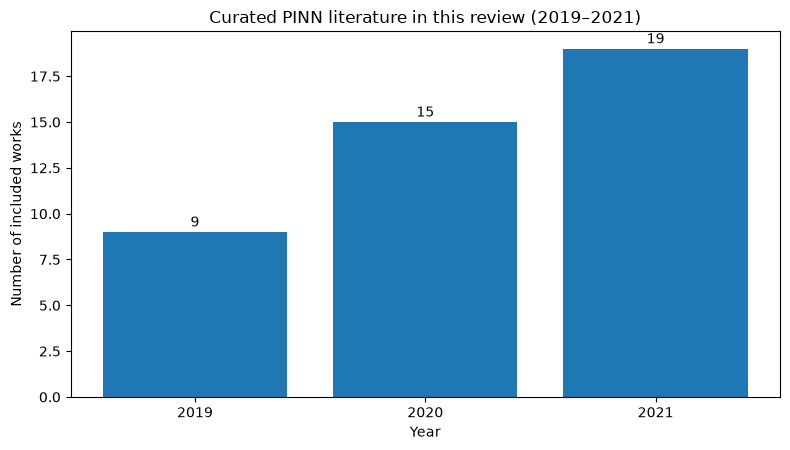

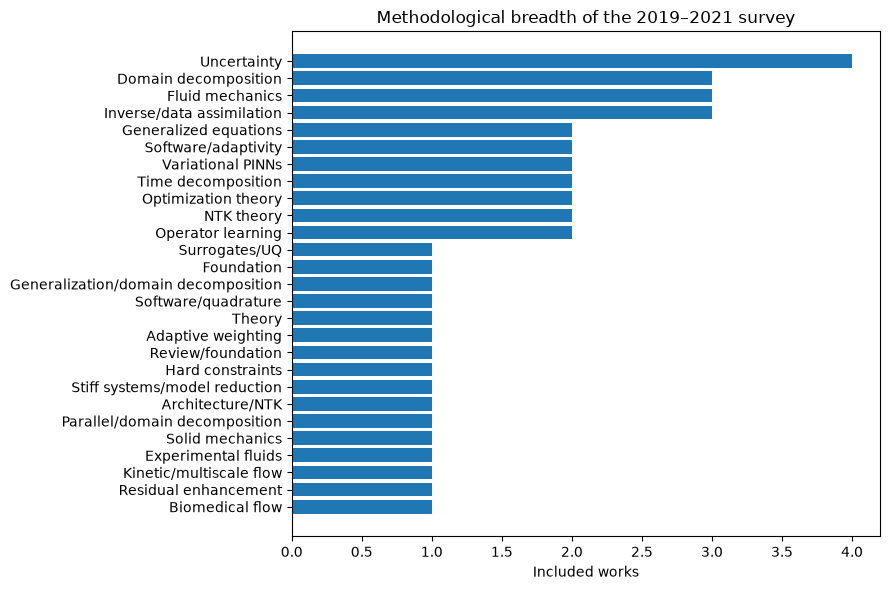

In [3]:
# Infographic: publication count by year and theme
fig, ax = plt.subplots(figsize=(8,4.6))
counts = lit.groupby('year').size()
ax.bar(counts.index.astype(str), counts.values)
ax.set_title('Curated PINN literature in this review (2019–2021)')
ax.set_xlabel('Year'); ax.set_ylabel('Number of included works')
for i,v in enumerate(counts.values): ax.text(i, v+0.3, str(v), ha='center')
fig.tight_layout()
fig.savefig(ASSET_DIR/'survey_by_year.png', dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(9,6))
top = lit['theme'].value_counts().sort_values()
ax.barh(top.index, top.values)
ax.set_title('Methodological breadth of the 2019–2021 survey')
ax.set_xlabel('Included works')
fig.tight_layout()
fig.savefig(ASSET_DIR/'survey_by_theme.png', dpi=180)
plt.show()

## 2. Original PINN formulation: a constrained function approximation problem

Let a differential equation be written abstractly as

$$
\mathcal N[u](\mathbf x,t;\boldsymbol\lambda)=0,
$$

with initial/boundary observations and perhaps sparse measurements. A neural network $u_\theta$ replaces the unknown field. Automatic differentiation constructs the residual

$$
f_\theta(\mathbf x,t)=\mathcal N[u_\theta](\mathbf x,t;\boldsymbol\lambda).
$$

The original formulation minimizes a weighted sum:

$$
\mathcal L=\lambda_f\frac{1}{N_f}\sum_i|f_\theta(\mathbf x_i,t_i)|^2+
\lambda_b\frac{1}{N_b}\sum_j|\mathcal B[u_\theta]-g_j|^2+
\lambda_d\frac{1}{N_d}\sum_k|u_\theta-y_k|^2.
$$

For an inverse problem, unknown physical parameters $\boldsymbol\lambda$ are simply added to the trainable parameter set. This is elegant, but it creates a multi-objective optimization problem whose terms can have very different units, curvature, and gradient scales.

In [4]:
class MLP(nn.Module):
    def __init__(self, in_dim=1, out_dim=1, width=32, depth=3):
        super().__init__()
        layers=[]
        dims=[in_dim]+[width]*depth+[out_dim]
        for i in range(len(dims)-1):
            layers.append(nn.Linear(dims[i],dims[i+1]))
            if i < len(dims)-2: layers.append(nn.Tanh())
        self.net=nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m,nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    def forward(self,x): return self.net(x)

def derivative(y,x,order=1):
    out=y
    for _ in range(order):
        out=torch.autograd.grad(out,x,torch.ones_like(out),create_graph=True,retain_graph=True)[0]
    return out

## 3. Experiment A — soft-constraint weights are part of the numerical method

We solve

$$u''(x)+\pi^2\sin(\pi x)=0,\qquad u(0)=u(1)=0,$$

whose exact solution is $u(x)=\sin(\pi x)$. The network and collocation set are unchanged; only the boundary-loss weight changes. This isolates the effect of the soft-constraint balance.

In [5]:
def train_poisson(lambda_bc, epochs=450):
    torch.manual_seed(SEED)
    model=MLP(width=28,depth=3).to(device)
    x_f=torch.linspace(0,1,64,device=device).view(-1,1).requires_grad_(True)
    xb=torch.tensor([[0.0],[1.0]],device=device)
    opt=torch.optim.Adam(model.parameters(),lr=2e-3)
    hist=[]
    for ep in range(epochs):
        opt.zero_grad()
        u=model(x_f); uxx=derivative(u,x_f,2)
        lf=((uxx+(math.pi**2)*torch.sin(math.pi*x_f))**2).mean()
        lb=(model(xb)**2).mean()
        loss=lf+lambda_bc*lb
        loss.backward(); opt.step()
        if ep%25==0: hist.append((ep,float(lf.detach()),float(lb.detach()),float(loss.detach())))
    x=torch.linspace(0,1,300,device=device).view(-1,1)
    with torch.no_grad(): pred=model(x).cpu().numpy().ravel()
    exact=np.sin(np.pi*x.cpu().numpy().ravel())
    l2=np.linalg.norm(pred-exact)/np.linalg.norm(exact)
    b_err=max(abs(pred[0]),abs(pred[-1]))
    return model,np.array(hist),x.cpu().numpy().ravel(),pred,exact,l2,b_err

weights=[0.1,1.0,10.0,100.0]
poisson={w:train_poisson(w) for w in weights}
summary=pd.DataFrame([{'lambda_bc':w,'relative_L2':poisson[w][5],'max_boundary_error':poisson[w][6]} for w in weights])
display(summary)

,lambda_bc,relative_L2,max_boundary_error
0,0.1,0.419341,0.587830
1,1.0,0.004318,0.005635
2,10.0,0.001142,0.001099
3,100.0,0.002971,0.001026


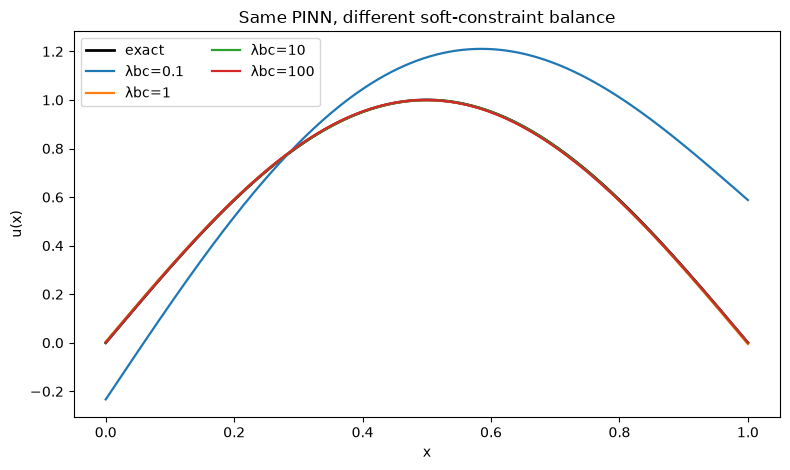

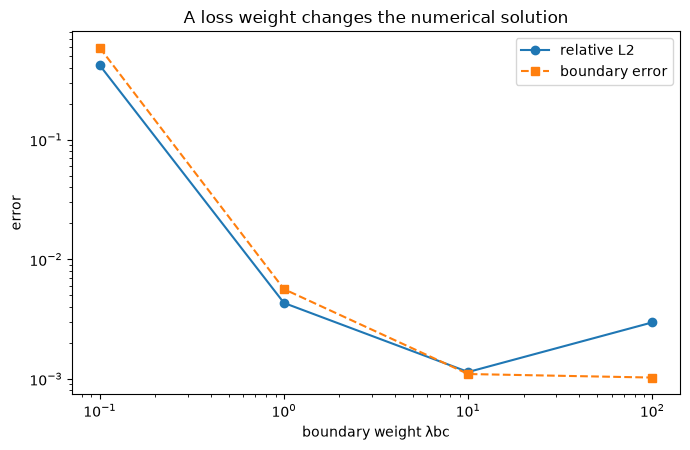

In [6]:
fig, ax = plt.subplots(figsize=(8,4.8))
ax.plot(poisson[1.0][2],poisson[1.0][4],'k-',lw=2,label='exact')
for w in weights:
    ax.plot(poisson[w][2],poisson[w][3],lw=1.6,label=f'λbc={w:g}')
ax.set_xlabel('x'); ax.set_ylabel('u(x)'); ax.set_title('Same PINN, different soft-constraint balance')
ax.legend(ncol=2); fig.tight_layout(); fig.savefig(ASSET_DIR/'soft_constraint_solutions.png',dpi=180); plt.show()

fig, ax = plt.subplots(figsize=(7,4.6))
ax.loglog(summary.lambda_bc,summary.relative_L2,'o-',label='relative L2')
ax.loglog(summary.lambda_bc,summary.max_boundary_error,'s--',label='boundary error')
ax.set_xlabel('boundary weight λbc'); ax.set_ylabel('error'); ax.set_title('A loss weight changes the numerical solution')
ax.legend(); fig.tight_layout(); fig.savefig(ASSET_DIR/'soft_constraint_weight_sweep.png',dpi=180); plt.show()

### Interpretation

A larger boundary weight does not monotonically improve the full solution. Too small a weight permits boundary drift; too large a weight can devote most updates to two boundary points and slow reduction of the interior residual. This is the optimization issue later formalized through gradient statistics and NTK blocks.

## 4. Experiment B — an inverse problem in the original PINN style

We infer the decay coefficient $k$ from sparse noisy observations of

$$y'(t)=-k y(t),\qquad y(0)=1.$$

The network approximates $y(t)$ while $\log k$ is a trainable scalar. The exponential parameterization guarantees $k>0$.

true k = 1.7 estimated k = 1.6425327062606812


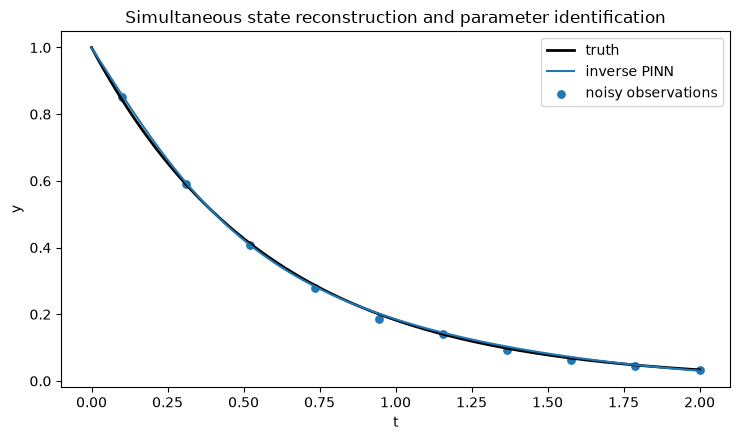

In [7]:
class InverseDecay(nn.Module):
    def __init__(self):
        super().__init__(); self.net=MLP(width=24,depth=2); self.log_k=nn.Parameter(torch.tensor(-0.3))
    def forward(self,t): return self.net(t)
    @property
    def k(self): return torch.exp(self.log_k)

k_true=1.7
rng=np.random.default_rng(SEED)
t_data=np.linspace(0.1,2.0,10)
y_data=np.exp(-k_true*t_data)+rng.normal(0,0.008,len(t_data))
td=torch.tensor(t_data,dtype=torch.float32,device=device).view(-1,1)
yd=torch.tensor(y_data,dtype=torch.float32,device=device).view(-1,1)
tf=torch.linspace(0,2,80,device=device).view(-1,1).requires_grad_(True)
t0=torch.zeros(1,1,device=device)
model_inv=InverseDecay().to(device); opt=torch.optim.Adam(model_inv.parameters(),lr=2e-3)
kh=[]
for ep in range(650):
    opt.zero_grad(); y=model_inv(tf); yt=derivative(y,tf,1)
    lf=((yt+model_inv.k*y)**2).mean(); lic=(model_inv(t0)-1).pow(2).mean(); ld=((model_inv(td)-yd)**2).mean()
    loss=lf+10*lic+5*ld; loss.backward(); opt.step()
    if ep%20==0: kh.append(float(model_inv.k.detach()))
print('true k =',k_true,'estimated k =',float(model_inv.k.detach()))

tplot=torch.linspace(0,2,300,device=device).view(-1,1)
with torch.no_grad(): yp=model_inv(tplot).cpu().numpy().ravel()
fig, ax=plt.subplots(figsize=(7.5,4.5))
ax.plot(tplot.cpu(),np.exp(-k_true*tplot.cpu().numpy()),'k-',lw=2,label='truth')
ax.plot(tplot.cpu(),yp,label='inverse PINN')
ax.scatter(t_data,y_data,s=28,label='noisy observations')
ax.set_xlabel('t'); ax.set_ylabel('y'); ax.set_title('Simultaneous state reconstruction and parameter identification')
ax.legend(); fig.tight_layout(); fig.savefig(ASSET_DIR/'inverse_decay.png',dpi=180); plt.show()

## 5. Experiment C — Stiff-PINN through quasi-steady-state reduction

Consider a consecutive reaction

$$A\xrightarrow{k_1}B\xrightarrow{k_2}C,\qquad k_2\gg k_1.$$

The intermediate $B$ evolves on a fast time scale and has a very small amplitude. A vanilla PINN must represent both the $O(1)$ slow variables and an $O(k_1/k_2)$ intermediate while making the fast residual small. Under the QSSA,

$$0\approx k_1A-k_2B\quad\Rightarrow\quad B\approx \frac{k_1}{k_2}A,$$

and the trainable system becomes

$$A'=-k_1A,\qquad C'=k_1A.$$

This mirrors the central Stiff-PINN idea: use mechanistic reduction to remove the most damaging stiffness before training.

In [8]:
k1,k2=1.0,500.0
T=3.0

def exact_kin(t):
    A=np.exp(-k1*t)
    B=k1/(k2-k1)*(np.exp(-k1*t)-np.exp(-k2*t))
    C=1-A-B
    return A,B,C

class FullKinetics(nn.Module):
    def __init__(self): super().__init__(); self.net=MLP(out_dim=3,width=36,depth=3)
    def forward(self,t): return self.net(t)
class QSSAKinetics(nn.Module):
    def __init__(self): super().__init__(); self.net=MLP(out_dim=2,width=28,depth=3)
    def forward(self,t): return self.net(t)

tf=torch.linspace(0,T,100,device=device).view(-1,1).requires_grad_(True)
t0=torch.zeros(1,1,device=device)

full=FullKinetics().to(device); opt=torch.optim.Adam(full.parameters(),lr=1.5e-3)
for ep in range(550):
    opt.zero_grad(); Y=full(tf); A,B,C=Y[:,0:1],Y[:,1:2],Y[:,2:3]
    At,Bt,Ct=[derivative(v,tf,1) for v in (A,B,C)]
    r1=At+k1*A; r2=Bt-k1*A+k2*B; r3=Ct-k2*B
    lf=(r1.square().mean()+r2.square().mean()+r3.square().mean())
    lic=((full(t0)-torch.tensor([[1.,0.,0.]],device=device))**2).mean()
    loss=lf+20*lic; loss.backward(); opt.step()

qssa=QSSAKinetics().to(device); opt=torch.optim.Adam(qssa.parameters(),lr=1.5e-3)
for ep in range(550):
    opt.zero_grad(); AC=qssa(tf); A,C=AC[:,0:1],AC[:,1:2]
    At,Ct=derivative(A,tf,1),derivative(C,tf,1)
    lf=((At+k1*A)**2).mean()+((Ct-k1*A)**2).mean()
    lic=((qssa(t0)-torch.tensor([[1.,0.]],device=device))**2).mean()
    cons=((A+C-1)**2).mean()
    loss=lf+20*lic+2*cons; loss.backward(); opt.step()

t=np.linspace(0,T,500); Ae,Be,Ce=exact_kin(t)
tt=torch.tensor(t,dtype=torch.float32,device=device).view(-1,1)
with torch.no_grad():
    Yf=full(tt).cpu().numpy(); Yq=qssa(tt).cpu().numpy()
Aq,Cq=Yq[:,0],Yq[:,1]; Bq=(k1/k2)*Aq
err_full=np.linalg.norm(Yf-np.c_[Ae,Be,Ce])/np.linalg.norm(np.c_[Ae,Be,Ce])
err_q=np.linalg.norm(np.c_[Aq,Bq,Cq]-np.c_[Ae,Be,Ce])/np.linalg.norm(np.c_[Ae,Be,Ce])
print({'full_PINN_relative_L2':err_full,'QSSA_PINN_relative_L2':err_q,
       'full_B_relative_L2':np.linalg.norm(Yf[:,1]-Be)/(np.linalg.norm(Be)+1e-12),
       'QSSA_B_relative_L2':np.linalg.norm(Bq-Be)/(np.linalg.norm(Be)+1e-12)})

{'full_PINN_relative_L2': np.float64(1.4687372226340156), 'QSSA_PINN_relative_L2': np.float64(0.017272508424296402), 'full_B_relative_L2': np.float64(1.3646222419463272), 'QSSA_B_relative_L2': np.float64(0.11310659387231242)}


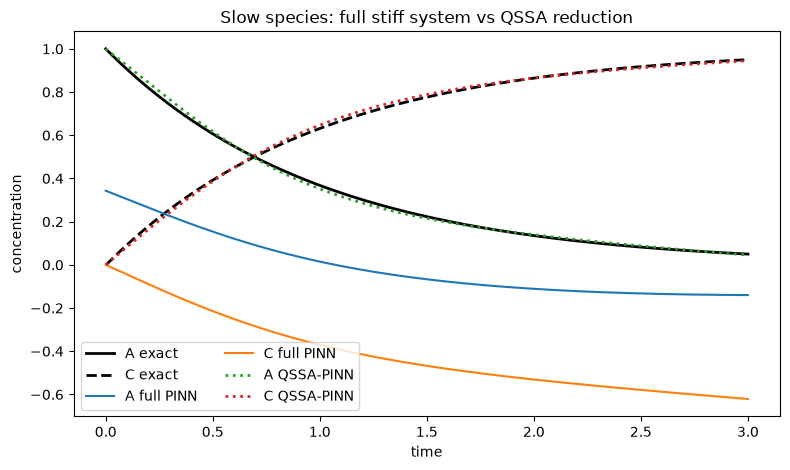

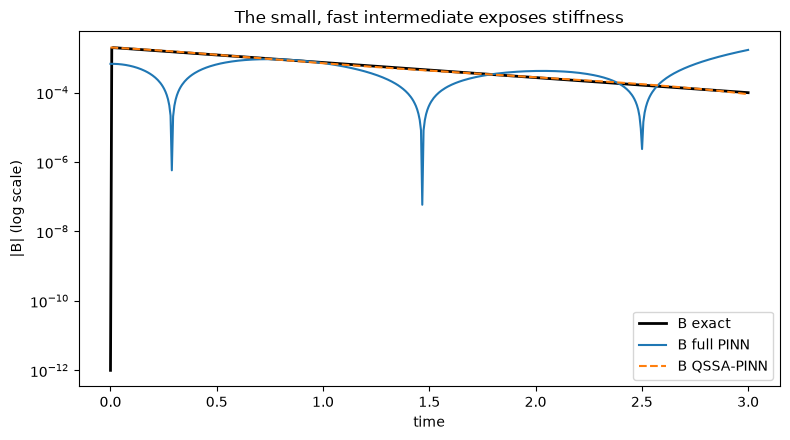

In [9]:
fig, ax=plt.subplots(figsize=(8,4.8))
ax.plot(t,Ae,'k-',lw=2,label='A exact'); ax.plot(t,Ce,'k--',lw=2,label='C exact')
ax.plot(t,Yf[:,0],label='A full PINN'); ax.plot(t,Yf[:,2],label='C full PINN')
ax.plot(t,Aq,':',lw=2,label='A QSSA-PINN'); ax.plot(t,Cq,':',lw=2,label='C QSSA-PINN')
ax.set_xlabel('time'); ax.set_ylabel('concentration'); ax.set_title('Slow species: full stiff system vs QSSA reduction')
ax.legend(ncol=2); fig.tight_layout(); fig.savefig(ASSET_DIR/'stiff_slow_species.png',dpi=180); plt.show()

fig, ax=plt.subplots(figsize=(8,4.5))
ax.semilogy(t,Be+1e-12,'k-',lw=2,label='B exact')
ax.semilogy(t,np.abs(Yf[:,1])+1e-12,label='B full PINN')
ax.semilogy(t,np.abs(Bq)+1e-12,'--',label='B QSSA-PINN')
ax.set_xlabel('time'); ax.set_ylabel('|B| (log scale)'); ax.set_title('The small, fast intermediate exposes stiffness')
ax.legend(); fig.tight_layout(); fig.savefig(ASSET_DIR/'stiff_intermediate.png',dpi=180); plt.show()

The reduced model is not “more neural.” It is **better posed for gradient training**. The important lesson from Stiff-PINN is that physical modeling and machine learning are complementary: QSSA supplies a scientifically justified coordinate/system reduction, and the PINN solves the reduced inverse/forward problem.

## 6. Experiment D — empirical neural tangent kernels for PINN loss blocks

Near initialization, gradient descent on a wide network is approximately governed by a kernel. For a PINN, there is not one homogeneous target: boundary outputs and PDE residuals have separate Jacobians and therefore separate kernel blocks.

For outputs $z(\theta)$, the empirical NTK is

$$K=J_\theta z\,J_\theta z^\top.$$

Large eigenvalues correspond to directions learned quickly; small eigenvalues correspond to slowly learned directions. If the residual block has a much larger trace or a very different spectrum from the boundary block, a fixed unweighted sum gives unequal convergence rates.

In [10]:
# Empirical NTK for the Poisson PINN at initialization.
torch.manual_seed(SEED)
ntk_model=MLP(width=24,depth=2).to(device)
xr=torch.linspace(0.05,0.95,12,device=device).view(-1,1).requires_grad_(True)
xb=torch.tensor([[0.0],[1.0]],device=device)
params=[p for p in ntk_model.parameters() if p.requires_grad]
P=sum(p.numel() for p in params)

def flat_grad(scalar):
    gs=torch.autograd.grad(scalar,params,retain_graph=True,allow_unused=True)
    return torch.cat([(torch.zeros_like(p) if g is None else g).reshape(-1) for g,p in zip(gs,params)])

ub=ntk_model(xb)
Jb=torch.stack([flat_grad(ub[i,0]) for i in range(len(xb))])
u=ntk_model(xr); uxx=derivative(u,xr,2); r=uxx+(math.pi**2)*torch.sin(math.pi*xr)
Jr=torch.stack([flat_grad(r[i,0]) for i in range(len(xr))])
Kb=(Jb@Jb.T).detach().cpu().numpy(); Kr=(Jr@Jr.T).detach().cpu().numpy()
eb=np.linalg.eigvalsh(Kb); er=np.linalg.eigvalsh(Kr)
trace_ratio=np.trace(Kr)/np.trace(Kb)
print('parameters:',P,'trace(K_residual)/trace(K_boundary)=',trace_ratio)
print('boundary eigenvalues:',eb)
print('residual eigenvalue range:',er.min(),er.max())

parameters: 673 trace(K_residual)/trace(K_boundary)= 1.1140354
boundary eigenvalues: [ 1.9608982 11.100237 ]
residual eigenvalue range: -2.6712422e-07 13.456529


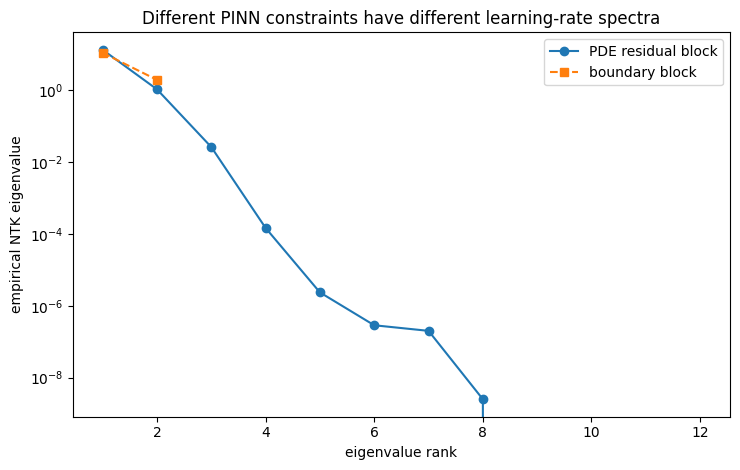

In [11]:
fig, ax=plt.subplots(figsize=(7.5,4.8))
ax.semilogy(np.arange(1,len(er)+1),np.sort(er)[::-1]+1e-16,'o-',label='PDE residual block')
ax.semilogy(np.arange(1,len(eb)+1),np.sort(eb)[::-1]+1e-16,'s--',label='boundary block')
ax.set_xlabel('eigenvalue rank'); ax.set_ylabel('empirical NTK eigenvalue')
ax.set_title('Different PINN constraints have different learning-rate spectra')
ax.legend(); fig.tight_layout(); fig.savefig(ASSET_DIR/'ntk_spectra.png',dpi=180); plt.show()

### What NTK theory added

The NTK analysis did not merely say “weights matter.” It supplied a mechanism:

- every loss block induces a kernel spectrum;
- gradient descent preferentially reduces modes associated with large eigenvalues;
- different constraints can converge at different rates even when their scalar losses appear comparable;
- adaptive weighting can be interpreted as changing the effective blockwise training rates;
- Fourier features and related architectures reshape the kernel eigenvectors/eigenvalues and improve multiscale learning.

This connects the empirical gradient-imbalance observations to a linearized training theory.

## 7. Advancement map, 2019–2021

| Problem exposed by early PINNs | Representative response in 2019–2021 | Core idea |
|---|---|---|
| Strong-form residuals require high derivatives | VPINN / hp-VPINN | Use weak/variational residuals and local test functions |
| Shocks and conservation laws | cPINN | Enforce flux conservation across subdomain interfaces |
| Large or multiscale domains | XPINN / parallel PINNs | Space–time decomposition with separate subnetworks |
| Long-time integration | PPINN | Parareal coarse/fine temporal decomposition |
| Unequal loss gradients | Gradient annealing, SA-PINN | Balance gradient statistics or learn pointwise weights |
| Frequency/spectral bias | Fourier features and NTK analysis | Reshape kernel eigenmodes to represent high frequencies |
| Stiff chemical kinetics | Stiff-PINN | Apply QSSA to remove fast variables before training |
| Noisy measurements and epistemic uncertainty | B-PINN, adversarial/total UQ | Bayesian or generative treatment of uncertainty |
| Fractional/nonlocal operators | fPINN, nPINN | Extend automatic-differentiation residuals to generalized operators |
| Complex boundary constraints | PFNN and hard ansatz methods | Satisfy boundary conditions by construction |
| Point placement inefficiency | RAR in DeepXDE | Add collocation points where residuals are largest |
| Lack of reusable software | DeepXDE, NeuralPDE | Encode equations symbolically and automate training |
| One network solves only one instance | DeepONet / PINO | Learn mappings between functions (operators), not a single solution |

In [10]:
# Compact survey tables for reuse/export
for year in [2019,2020,2021]:
    print('\nYEAR',year)
    display(lit[lit.year==year][['authors','title','theme','venue','identifier']].reset_index(drop=True))

lit.to_csv('/mnt/data/PINN_literature_2019_2021.csv',index=False)


YEAR 2019


,authors,title,theme,venue,identifier
0,"Raissi, Perdikaris & Karniadakis",Physics-informed neural networks: A deep learn...,Foundation,J. Computational Physics,10.1016/j.jcp.2018.10.045
1,"Pang, Lu & Karniadakis",fPINNs: Fractional physics-informed neural net...,Generalized equations,SIAM J. Scientific Computing,10.1137/18M1229845
2,Zhu et al.,Physics-constrained deep learning for high-dim...,Surrogates/UQ,J. Computational Physics,10.1016/j.jcp.2019.02.035
3,Yang & Perdikaris,Adversarial uncertainty quantification in phys...,Uncertainty,J. Computational Physics,10.1016/j.jcp.2019.05.027
4,Zhang et al.,Quantifying total uncertainty in physics-infor...,Uncertainty,J. Computational Physics,10.1016/j.jcp.2019.07.048
5,Lu et al.,DeepXDE: A deep learning library for solving d...,Software/adaptivity,arXiv:1907.04502,arXiv:1907.04502
6,"Kharazmi, Zhang & Karniadakis",Variational physics-informed neural networks f...,Variational PINNs,arXiv:1912.00873,arXiv:1912.00873
7,Meng et al.,PPINN: Parareal physics-informed neural networ...,Time decomposition,arXiv:1909.10145,arXiv:1909.10145
8,"Dwivedi, Parashar & Srinivasan",Distributed physics-informed neural network fo...,Domain decomposition,arXiv:1907.08967,arXiv:1907.08967



YEAR 2020


,authors,title,theme,venue,identifier
0,"Mao, Jagtap & Karniadakis",Physics-informed neural networks for high-spee...,Fluid mechanics,CMAME,10.1016/j.cma.2019.112789
1,"Jagtap, Kharazmi & Karniadakis",Conservative physics-informed neural networks ...,Domain decomposition,CMAME,10.1016/j.cma.2020.113028
2,Jagtap & Karniadakis,Extended physics-informed neural networks (XPI...,Domain decomposition,Commun. Computational Physics,10.4208/cicp.OA-2020-0164
3,Meng et al.,PPINN: Parareal physics-informed neural networ...,Time decomposition,CMAME,10.1016/j.cma.2020.113250
4,"Raissi, Yazdani & Karniadakis",Hidden fluid mechanics: Learning velocity and ...,Inverse/data assimilation,Science,10.1126/science.aaw4741
5,Tartakovsky et al.,Physics-informed deep neural networks for lear...,Inverse/data assimilation,Water Resources Research,10.1029/2019WR026731
6,He et al.,Physics-informed neural networks for multiphys...,Inverse/data assimilation,Advances in Water Resources,10.1016/j.advwatres.2020.103610
7,Kissas et al.,Machine learning in cardiovascular flows model...,Biomedical flow,CMAME,10.1016/j.cma.2019.112623
8,Pang et al.,nPINNs: Nonlocal physics-informed neural netwo...,Generalized equations,J. Computational Physics,10.1016/j.jcp.2020.109760
9,"Shin, Darbon & Karniadakis",On the convergence of physics-informed neural ...,Theory,Commun. Computational Physics,10.4208/cicp.OA-2020-0193



YEAR 2021


,authors,title,theme,venue,identifier
0,Karniadakis et al.,Physics-informed machine learning,Review/foundation,Nature Reviews Physics,10.1038/s42254-021-00314-5
1,Lu et al.,DeepXDE: A deep learning library for solving d...,Software/adaptivity,SIAM Review,10.1137/19M1274067
2,"Yang, Meng & Karniadakis",B-PINNs: Bayesian physics-informed neural netw...,Uncertainty,J. Computational Physics,10.1016/j.jcp.2020.109913
3,"Kharazmi, Zhang & Karniadakis",hp-VPINNs: Variational physics-informed neural...,Variational PINNs,CMAME,10.1016/j.cma.2020.113547
4,Sheng & Yang,PFNN: A penalty-free neural network method for...,Hard constraints,J. Computational Physics,10.1016/j.jcp.2020.110085
5,Ji et al.,Stiff-PINN: Physics-informed neural network fo...,Stiff systems/model reduction,J. Physical Chemistry A,10.1021/acs.jpca.1c05102
6,"Wang, Teng & Perdikaris",Understanding and mitigating gradient flow pat...,Optimization theory,SIAM J. Scientific Computing,10.1137/20M1318043
7,"Wang, Yu & Perdikaris",When and why PINNs fail to train: A neural tan...,NTK theory,J. Computational Physics,10.1016/j.jcp.2021.110768
8,"Wang, Wang & Perdikaris",On the eigenvector bias of Fourier feature net...,Architecture/NTK,CMAME,10.1016/j.cma.2021.113938
9,"Shukla, Jagtap & Karniadakis",Parallel physics-informed neural networks via ...,Parallel/domain decomposition,J. Computational Physics,10.1016/j.jcp.2021.110683


OSError: Cannot save file into a non-existent directory: '/mnt/data'

## 8. What remained unresolved at the end of 2021

1. **Optimization was still the bottleneck.** A small training loss did not guarantee uniform solution accuracy, and reliable automatic loss balancing was not settled.
2. **Stiffness and multiscale dynamics required problem-specific intervention.** QSSA, decomposition, Fourier features, and adaptive sampling helped, but no universal method existed.
3. **Forward-solver competitiveness was limited.** For standard low-dimensional forward problems, mature finite-difference/finite-element/spectral solvers were usually faster and more accurate.
4. **Error control was immature.** Early convergence and generalization results covered restricted PDE classes and assumptions.
5. **Benchmarking was fragmented.** Architecture, sampling, precision, optimizer, and stopping criteria varied greatly across papers.
6. **Operator learning was emerging as a different cost model.** DeepONet and PINO shifted the goal from solving one PDE instance to amortizing a family of solves.

## Practical checklist distilled from the 2019–2021 literature

- nondimensionalize equations and outputs;
- inspect each loss term and its gradient norm separately;
- use smooth activations for high-order derivatives;
- start with Adam and optionally finish with L-BFGS;
- consider hard constraints for simple boundary/initial conditions;
- use adaptive sampling for localized residuals;
- use domain/time decomposition for long or multiscale domains;
- reduce stiff mechanisms before training when justified;
- compare against a classical solver and report error, runtime, seeds, and collocation counts;
- do not treat a low aggregate loss as proof that every physical constraint is satisfied.

## References: four foundation papers emphasized in the experiments

1. Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). *Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations*. Journal of Computational Physics, 378, 686–707. DOI: 10.1016/j.jcp.2018.10.045.
2. Ji, W., Qiu, W., Shi, Z., Pan, S., & Deng, S. (2021). *Stiff-PINN: Physics-Informed Neural Network for Stiff Chemical Kinetics*. The Journal of Physical Chemistry A, 125(36), 8098–8106. DOI: 10.1021/acs.jpca.1c05102.
3. Wang, S., Teng, Y., & Perdikaris, P. (2021). *Understanding and Mitigating Gradient Flow Pathologies in Physics-Informed Neural Networks*. SIAM Journal on Scientific Computing, 43(5), A3055–A3081. DOI: 10.1137/20M1318043.
4. Wang, S., Yu, X., & Perdikaris, P. (2021). *When and why PINNs fail to train: A neural tangent kernel perspective*. Journal of Computational Physics. DOI: 10.1016/j.jcp.2021.110768.